# Importing Needed Packages

In [1]:
import pandas as pd
import pylab as pl
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
%matplotlib inline
import matplotlib.pyplot as plt

# Load The Datas

In [2]:
cell_df = pd.read_csv("heart.csv")
cell_df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# Data Preprocessing

In [6]:
cell_df.dtypes

,0
age,int64
sex,int64
cp,int64
trtbps,int64
chol,int64
fbs,int64
restecg,int64
thalachh,int64
exng,int64
oldpeak,float64


In [7]:
cell_df['oldpeak'] = cell_df['oldpeak'].astype('int')

In [8]:
cell_df.dtypes

,0
age,int64
sex,int64
cp,int64
trtbps,int64
chol,int64
fbs,int64
restecg,int64
thalachh,int64
exng,int64
oldpeak,int64


In [9]:
cell_df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0,2,0,2,1


In [10]:
X = np.asarray(cell_df[['age', 'sex', 'cp', 'chol', 'fbs', 'restecg', 'thalachh','exng','oldpeak','slp','caa','thall']])
X[0:5]

array([[ 63,   1,   3, 233,   1,   0, 150,   0,   2,   0,   0,   1],
       [ 37,   1,   2, 250,   0,   1, 187,   0,   3,   0,   0,   2],
       [ 41,   0,   1, 204,   0,   0, 172,   0,   1,   2,   0,   2],
       [ 56,   1,   1, 236,   0,   1, 178,   0,   0,   2,   0,   2],
       [ 57,   0,   0, 354,   0,   1, 163,   1,   0,   2,   0,   2]])

In [11]:
y = np.asarray(cell_df['output'])
y [0:5]

array([1, 1, 1, 1, 1])

In [12]:
from sklearn import preprocessing
X = preprocessing.StandardScaler().fit(X).transform(X)
X[0:5]

array([[ 0.9521966 ,  0.68100522,  1.97312292, -0.25633371,  2.394438  ,
        -1.00583187,  0.01544279, -0.69663055,  1.15447496, -2.27457861,
        -0.71442887, -2.14887271],
       [-1.91531289,  0.68100522,  1.00257707,  0.07219949, -0.41763453,
         0.89896224,  1.63347147, -0.69663055,  2.08978489, -2.27457861,
        -0.71442887, -0.51292188],
       [-1.47415758, -1.46841752,  0.03203122, -0.81677269, -0.41763453,
        -1.00583187,  0.97751389, -0.69663055,  0.21916503,  0.97635214,
        -0.71442887, -0.51292188],
       [ 0.18017482,  0.68100522,  0.03203122, -0.19835726, -0.41763453,
         0.89896224,  1.23989692, -0.69663055, -0.7161449 ,  0.97635214,
        -0.71442887, -0.51292188],
       [ 0.29046364, -1.46841752, -0.93851463,  2.08204965, -0.41763453,
         0.89896224,  0.58393935,  1.43548113, -0.7161449 ,  0.97635214,
        -0.71442887, -0.51292188]])

# Split Train and test Data

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (242, 12) (242,)
Test set: (61, 12) (61,)


# Modeling

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
LR = LogisticRegression(C=0.01, solver='liblinear').fit(X_train,y_train)
LR

LogisticRegression(C=0.01, solver='liblinear')

In [15]:
yhat = LR.predict(X_test)
yhat

array([1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1])

In [16]:
yhat_prob = LR.predict_proba(X_test)
yhat_prob

array([[0.40233085, 0.59766915],
       [0.73158386, 0.26841614],
       [0.36778499, 0.63221501],
       [0.20350817, 0.79649183],
       [0.4313022 , 0.5686978 ],
       [0.4834101 , 0.5165899 ],
       [0.62273191, 0.37726809],
       [0.24425   , 0.75575   ],
       [0.50031862, 0.49968138],
       [0.35016382, 0.64983618],
       [0.41678519, 0.58321481],
       [0.22090728, 0.77909272],
       [0.38619103, 0.61380897],
       [0.57972734, 0.42027266],
       [0.3311612 , 0.6688388 ],
       [0.84450798, 0.15549202],
       [0.29397294, 0.70602706],
       [0.30140983, 0.69859017],
       [0.69694729, 0.30305271],
       [0.42959478, 0.57040522],
       [0.25110183, 0.74889817],
       [0.4079969 , 0.5920031 ],
       [0.79748937, 0.20251063],
       [0.4037531 , 0.5962469 ],
       [0.45675824, 0.54324176],
       [0.75752487, 0.24247513],
       [0.57979672, 0.42020328],
       [0.22528402, 0.77471598],
       [0.43635474, 0.56364526],
       [0.80796581, 0.19203419],
       [0.

# Evaluation

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
print(confusion_matrix(y_test, yhat, labels=[1,0]))

[[33  3]
 [ 5 20]]


Confusion matrix, without normalization
[[33  3]
 [ 5 20]]


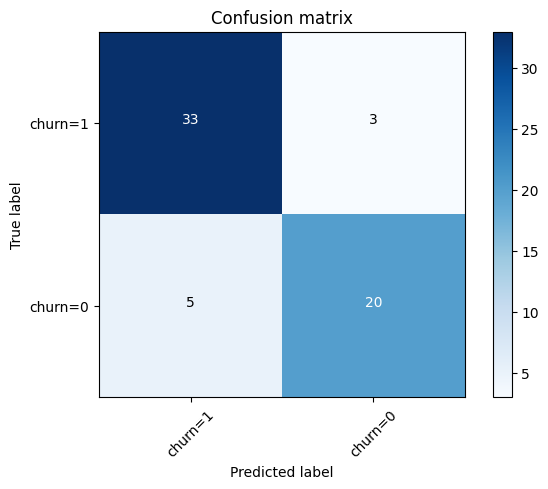

In [19]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, yhat, labels=[1,0])
np.set_printoptions(precision=2)


# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['churn=1','churn=0'],normalize= False,  title='Confusion matrix')

In [20]:
print (classification_report(y_test, yhat))


              precision    recall  f1-score   support

           0       0.87      0.80      0.83        25
           1       0.87      0.92      0.89        36

    accuracy                           0.87        61
   macro avg       0.87      0.86      0.86        61
weighted avg       0.87      0.87      0.87        61

